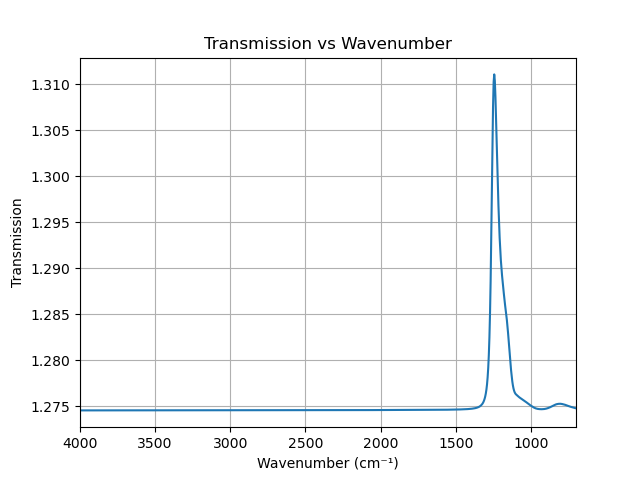

In [286]:
%matplotlib widget
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 



file_path = "/Users/josephschellenberg/Downloads/Fresnell.xlsx"
# Load the Excel file (adjust path/filename as needed)
df = pd.read_excel("/Users/josephschellenberg/Downloads/Fresnell/Fresnell.xlsx")  # Or .csv with pd.read_csv

# Extract columns into arrays
wave_numbers = df["wave_numbers"].values
n0_array = df["n0"].values
k0_array = df["k0"].values
n1_array = df["n1"].values
k1_array = df["k1"].values
n2_array = df["n2"].values
k2_array = df["k2"].values  




def cos(th):
    return np.cos(th*np.pi/180) 

def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2)) 

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi 

def sin(th):
    return np.sin(th*np.pi/180 ) 

# 3 Returns transmitted angle from incident angle
def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))

# 4 General form of fresnel coefficients for s polarized light (perpindicular electric field) 
def r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(((ni+1j*ki)/mui*cos_thi-(nt+1j*kt)/mut*cos_tht)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht)) 

def t_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)  
    return((2*(ni+1j*ki)/mui*cos_thi)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

# 5 General form of fresnel coefficients for p polarized light (parrallel electric field)  

def r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((-(nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))

def t_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((2*(ni+1j*ki)/mui*cos_thi)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))  


#transmission matrix 

def D_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((1/t_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12))*(np.array([[1,r_p(ni, nt, ki, kt, thi, mui=1, mut=1)],[r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12),1]])))  

def D_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((1/t_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12))*(np.array([[1,r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12)],[r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12),1]])))  


# propagation matrix wich is independant of polarazation

def P(ni, nt, ki, kt, thi, d, Wavelength):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(np.array([[np.exp(1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength),0],[0,np.exp(-1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength)]]))



# 6 total fresnel coefficints s polarized

def t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    return(1/M_11) 


def t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0]
    return(1/M_11)   

def r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    M_21 = M[1, 0]
    return(M_21/M_11) 

def r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0] 
    M_21 = M[1, 0]
    return(M_21/M_11)   

def mag_r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array(np.abs(r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)) )

def mag_r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(r_s_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])

def mag_t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array(np.abs(t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)))

def mag_t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(t_s_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0]) 

plt.clf()

# define d and theta first as global variables
d = .00010 
  

#creating two empty lists for reflectance of parrallel light and the reflectance coefficient. my for loop will add terms to this list using append. 
rparrallel = []
Rparrallel = [] 
Tparrallel = []
Aparrallel = []
#create my loop using in zip to make sure that the values in my array stay  lined up
for n0, k0, n1, k1, n2, k2, Wavenumber in zip(n0_array, k0_array, n1_array, k1_array, n2_array, k2_array, wave_numbers): 
    Wavelength = 1E4 / Wavenumber 
 # converts wavenumber in inverse cm to wavelength in standard cm units.   
    th0=80  
    cos_th0 = cos(th0)
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    th2 = snells(n1, n2, k1, k2, th1)
    cos_th2= cos(th2) 
    r = np.abs(r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)) 
    #r = mag_r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
    R = r**2
    t = t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
    #t = mag_t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
    T = np.real((n2 * cos_th2) / (n0 * cos_th0)) * np.abs(t)**2
    

    loss = 1 - R - T

    #print(f"WN={Wavenumber:.0f}:  R={R:.3f},  T={T:.3f},  loss={loss:.3f}")
    a = 1 - R
    A = np.log10(1/a)
    rparrallel.append(r) 
    Rparrallel.append(R)  
    Aparrallel.append(A)
    Tparrallel.append(T)  
#quick graph
plt.plot(wave_numbers, Aparrallel)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Transmission")
plt.title("Transmission vs Wavenumber")
plt.gca().invert_xaxis()  
plt.xlim(4000, 700)
plt.grid(True)
plt.show()



This code is working correctly now. I will use what I have developed here on 20230723-test